# Sigmoid可视化

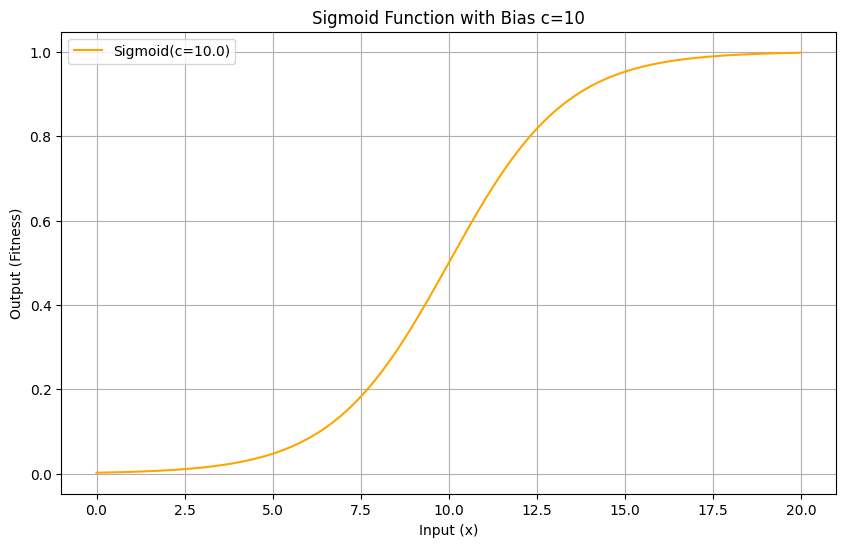

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, k, c):
    return 1 / (1 + np.exp(-k * (x - c)))

# 定义输入范围
x_values = np.linspace(0, 20, 400)  # 输入值范围从 0 到 20

# 设置参数
k = 0.6  # 控制陡峭程度
c = 10.0  # 偏置项，确保 x=10 时输出为 0.5

# 计算对应的 Sigmoid 值
y_values = sigmoid(x_values, k, c)

# 绘制 Sigmoid 函数图像
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label=f'Sigmoid(c={c})', color='orange')
plt.title('Sigmoid Function with Bias c=10')
plt.xlabel('Input (x)')
plt.ylabel('Output (Fitness)')
plt.grid(True)
# plt.axhline(0.5, color='red', linestyle='--', label='Fitness=0.5 at x=10')
# plt.axvline(10, color='red', linestyle='--', label='x=10')
plt.legend()
plt.show()

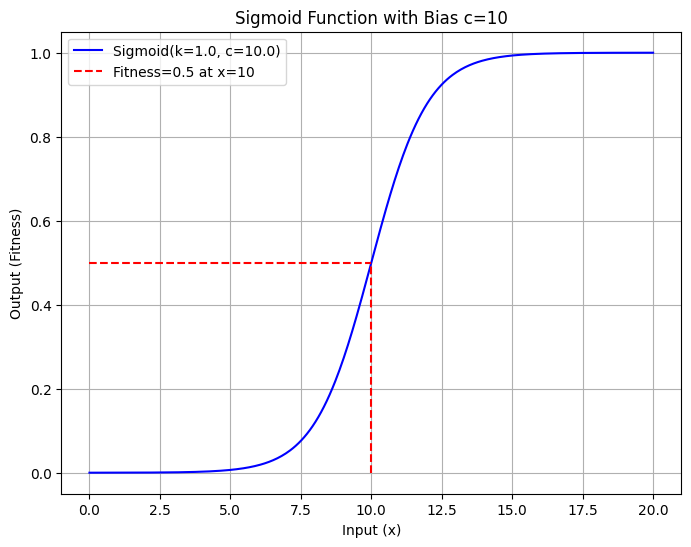

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, k, c):
    return 1 / (1 + np.exp(-k * (x - c)))

# 定义输入范围
x_values = np.linspace(0, 20, 400)  # 输入值范围从 0 到 20

# 设置参数
k = 1.0  # 控制陡峭程度
c = 10.0  # 偏置项，确保 x=10 时输出为 0.5

# 计算对应的 Sigmoid 值
y_values = sigmoid(x_values, k, c)

# 找到 x=10 时对应的 y 值（即 y=0.5）
x_intersect = 10.0
y_intersect = 0.5

# 绘制 Sigmoid 函数图像
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label=f'Sigmoid(k={k}, c={c})', color='blue')

# 绘制水平线（从 x=0 到 x=10）
plt.plot([x_values.min(), x_intersect], [y_intersect, y_intersect], color='red', linestyle='--', label='Fitness=0.5 at x=10')

# 绘制垂直线（从 y=0 到 y=0.5）
plt.plot([x_intersect, x_intersect], [0, y_intersect], color='red', linestyle='--')

# 设置图像属性
plt.title('Sigmoid Function with Bias c=10')
plt.xlabel('Input (x)')
plt.ylabel('Output (Fitness)')
plt.grid(True)
plt.legend()
plt.show()

# 图网络三阶段


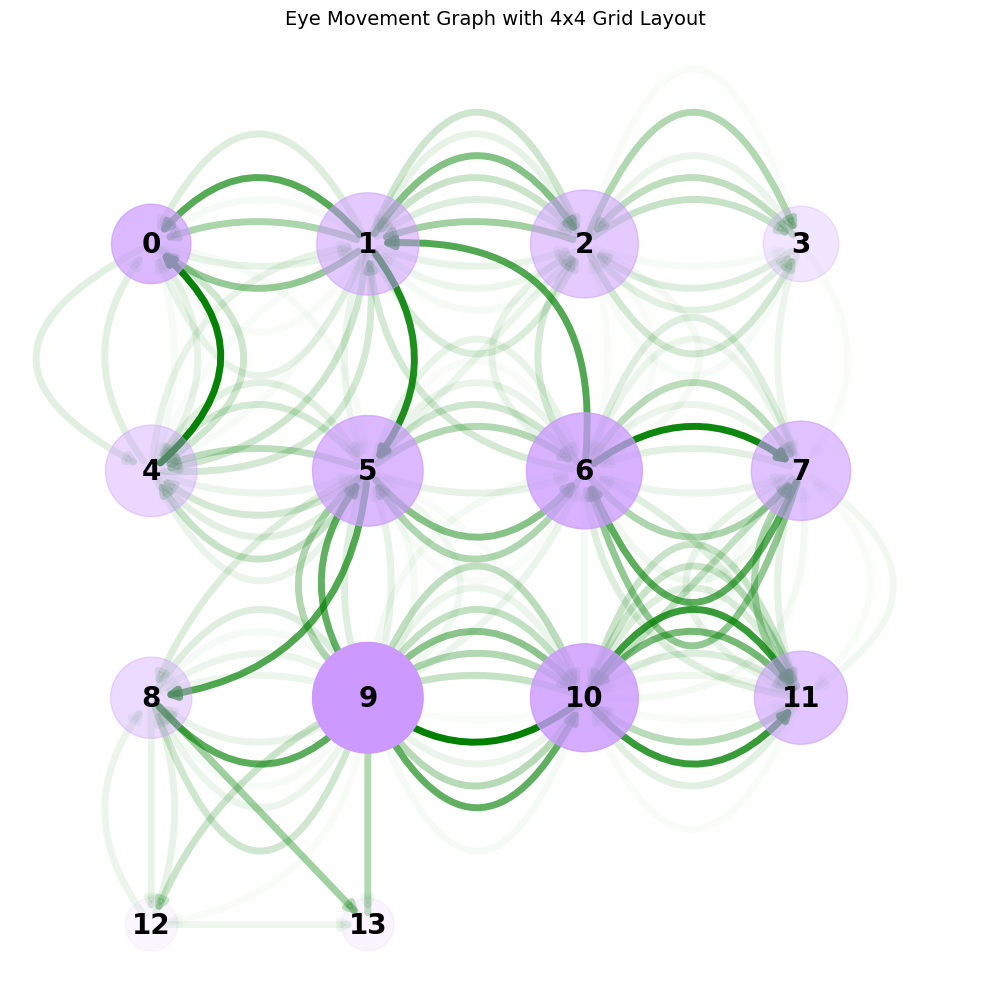

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np


# 假设 GazeRecord 类定义如下
class GazeRecord:
    def __init__(self, source_container, target_container, timestamp, duration_weight, is_selected):
        self.source_container = source_container
        self.target_container = target_container
        self.timestamp = timestamp
        self.duration_weight = duration_weight
        self.is_selected = is_selected

# 余弦距离 = 1 - 余弦相似度
def cosine_distance(v1, v2):
    points1 = get_point(v1)
    points2 = get_point(v2)

    vec1 = np.array(points1).flatten() # 展平，二维数组——列表。
    vec2 = np.array(points2).flatten()

    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 1.0
    similarity = np.dot(vec1, vec2) / (norm1 * norm2)
    return 1.0  - similarity

def build_graph(records):
    """
    构建有向加权多重图。

    参数:
    - records: 包含眼动记录的列表，每个记录是 GazeRecord 对象。
    """
    G = nx.MultiDiGraph()
    for record in records:
        G.add_edge(
            record.source_container,
            record.target_container,
            key=record.timestamp,
            duration_weight=record.duration_weight,
            is_selected=record.is_selected
        )
    return G

def visualize_gaze_graph(G):
    """
    可视化眼动图，节点按4x4网格布局，边的透明度与权重相关。
    修改点：当两节点间存在多条边时，使用不同弧度的曲线绘制，避免边重叠
    """
    # 1. 生成 4x4 网格布局的节点坐标
    pos = {}
    for i in range(16):  # i即为容器的整数索引（0-15）
        x = i % 4  # 列
        y = 3- (i // 4)  # 行
        pos[i] = (x, y)  # 修改点：节点键改为整数

    # 2. 提取边的权重并归一化（逻辑不变）
    edges = list(G.edges(data=True))
    weights = [data["duration_weight"] for u, v, data in edges]
    min_weight = min(weights)
    max_weight = max(weights)
    alphas = [(w - min_weight) / (max_weight - min_weight) for w in weights]

    # 3. 创建画布（逻辑不变）
    plt.figure(figsize=(10, 10))

    # 4. 绘制节点（节点标签为整数索引）
    # 计算度中心性（逻辑不变）
    out_centrality = nx.out_degree_centrality(G)
    in_centrality = nx.in_degree_centrality(G)
    degree_centrality = {node: out_centrality[node] + in_centrality[node] for node in G.nodes}

    # 计算总入边注视时间（逻辑不变）
    node_in_duration = defaultdict(int)
    for u, v, data in G.edges(data=True):
        node_in_duration[v] += data["duration_weight"]

    # 归一化节点大小和透明度（逻辑不变）
    max_size = 2500
    min_size = 500
    node_sizes = [min_size + (degree_centrality[node] * (max_size - min_size)) for node in G.nodes]

    max_alpha_duration = max(node_in_duration.values(), default=1)
    node_alphas = [node_in_duration[node] / max_alpha_duration if node in node_in_duration else 0.5 for node in G.nodes]

    node_colors = [(0.8, 0.6, 1, alpha) for alpha in node_alphas]

    # 绘制节点（节点键为整数，标签自动显示为整数）
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        label="Container"
    )

    # 5. 绘制边（逐个处理，支持多重边）
    # 新增多边统计逻辑
    edges = list(G.edges(data=True))
    edge_counts_total = defaultdict(int)
    for u, v, data in edges:
        edge_counts_total[(u, v)] += 1  # 统计每个节点对的边数量

    edge_positions = defaultdict(int)  # 跟踪各节点对的边绘制顺序

    # 修改边绘制逻辑
    for i, (u, v, data) in enumerate(edges):
        alpha = alphas[i]
        total = edge_counts_total[(u, v)]
        current_pos = edge_positions[(u, v)]
        edge_positions[(u, v)] += 1

        # 多边时启用曲线绘制
        if total >= 2:
            # 动态计算弧度（交替正负方向）
            rad = 0.2 * (current_pos + 1) * (-1 if current_pos % 2 else 1)
            connectionstyle = f'arc3,rad={rad}'
        else:
            connectionstyle = 'arc3'  # 单边保持直线

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            width=5,
            alpha=alpha,
            edge_color="green",
            arrows=True,
            arrowsize=15,
            connectionstyle=connectionstyle  # 添加曲线样式参数
        )

    # 6. 添加节点标签
    nx.draw_networkx_labels(G, pos, font_size=20,font_color="black", font_family="sans-serif",font_weight="heavy")

    # 7. 图形设置
    # plt.title("Eye Movement Graph with 4x4 Grid Layout", fontsize=14)
    plt.axis("off")  # 隐藏坐标轴
    plt.tight_layout()
    plt.show()


import json
# 读取 JSON 文件
with open(r'D:\EyeTrackerVase\testA\20250731154108.json', 'r') as f:
    data = json.load(f)

# 构建 GazeRecord 对象列表
# 构建 GazeRecord 对象列表
records = []
for item in data['gaze_records']:  # 注意：从 'gaze_records' 字段中提取数据
    record = GazeRecord(
        source_container=item['source_container'],
        target_container=item['target_container'],
        timestamp=item['timestamp'],
        duration_weight=item['duration_weight'],
        is_selected=item['is_selected']
    )
    records.append(record)

# 构建图
G = build_graph(records)

# 可视化图
visualize_gaze_graph(G)